<a href="https://colab.research.google.com/github/DeepanshuSharma1607/house-price_and_average_happy_life_prediction/blob/main/notebook474ddf25d3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
arjunyadav99_indian_agricultural_mandi_prices_20232025_path = kagglehub.dataset_download('arjunyadav99/indian-agricultural-mandi-prices-20232025')

print('Data source import complete.')


100%|██████████| 10.1M/10.1M [00:00<00:00, 69.0MB/s]

Extracting files...


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Agriculture_price_dataset.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "arjunyadav99/indian-agricultural-mandi-prices-20232025",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_8982/4244756721.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'indian-agricultural-mandi-prices-20232025' dataset.
First 5 records:            STATE District Name        Market Name Commodity           Variety  \
0    Maharashtra        nashik  Lasalgaon(Niphad)     Wheat  Maharashtra 2189   
1    Maharashtra        satara              Patan    Tomato             Other   
2  Uttar Pradesh      mainpuri              Bewar    Potato             Local   
3      Rajasthan   chittorgarh          Nimbahera     Wheat             Other   
4      Rajasthan    pratapgarh         Pratapgarh     Onion             Other   

  Grade  Min_Price  Max_Price  Modal_Price Price Date  
0   FAQ     2172.0     2399.0       2300.0   6/6/2023  
1   FAQ     1000.0     1500.0       1250.0   6/6/2023  
2   FAQ      800.0      820.0        810.0   6/6/2023  
3   FAQ     2040.0     2668.0       2300.0   6/6/2023  
4   FAQ      476.0     1043.0        617.0   6/6/2023  


In [5]:
df.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [6]:
df.shape

(737392, 10)

In [7]:
df.tail()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
737387,Tamilnadu,namakkal,Kumarapalayam(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3000.0,3500.0,3500.0,6/11/2025
737388,Orissa,dhenkanal,Kamakhyanagar,Potato,Potato,Non-FAQ,1900.0,2200.0,2000.0,6/11/2025
737389,Tamilnadu,dindigul,Vedasanthur(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3500.0,4000.0,4000.0,6/11/2025
737390,Tamilnadu,virudhunagar,Virudhunagar(Uzhavar Sandhai ),Onion,Bellary,Local,2800.0,3000.0,3000.0,6/11/2025
737391,Haryana,yamuna nagar,Chhachrauli,Onion,Onion,FAQ,1500.0,3000.0,3000.0,6/11/2025


In [8]:
def unique_(x):
    print(df[x].nunique(),' - > ',df[x].unique())
    print("="*70)

In [9]:
df['Price Date'] = pd.to_datetime(df['Price Date'])
df['Year'] = df['Price Date'].dt.year
df['Month'] = df['Price Date'].dt.month

In [10]:
def preprocess(s):
    return str(s).lower().strip().replace(' ','_')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737392 entries, 0 to 737391
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   STATE          737392 non-null  object        
 1   District Name  737392 non-null  object        
 2   Market Name    737392 non-null  object        
 3   Commodity      737392 non-null  object        
 4   Variety        737392 non-null  object        
 5   Grade          737392 non-null  object        
 6   Min_Price      737392 non-null  float64       
 7   Max_Price      737392 non-null  float64       
 8   Modal_Price    737392 non-null  float64       
 9   Price Date     737392 non-null  datetime64[ns]
 10  Year           737392 non-null  int32         
 11  Month          737392 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), object(6)
memory usage: 61.9+ MB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
ls=['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade']
for i in ls:
    print(i)
    unique_(i)
    print('\n')
    df[i]=df[i].apply(preprocess)

STATE
30  - >  ['Maharashtra' 'Uttar Pradesh' 'Rajasthan' 'Haryana' 'West Bengal'
 'Himachal Pradesh' 'Gujarat' 'Meghalaya' 'Madhya Pradesh'
 'Andhra Pradesh' 'Kerala' 'Nagaland' 'Orissa' 'Karnataka' 'Assam'
 'Punjab' 'Jammu & Kashmir' 'Delhi' 'Chattisgarh' 'Bihar' ' Punjab'
 'Jammu and Kashmir' 'Chhattisgarh' 'Uttrakhand' 'Chandigarh' 'Manipur'
 'Tamilnadu' 'Tripura' 'Tamil Nadu' 'Gao']


District Name
373  - >  ['nashik' 'satara' 'mainpuri' 'chittorgarh' 'pratapgarh' 'bharatpur'
 'ambala' 'birbhum' 'mandi' 'sambhal' 'panipat' 'bhavnagar' 'bareilly'
 'kaithal' 'kangra' 'west garo hills' 'rajgarh' 'sagar' 'nalgonda' 'anand'
 'ernakulam' 'satna' 'mandla' 'patan' 'amethi' 'sonipat' 'bulandshahar'
 'jhabua' 'mokokchung' 'una' 'thiruvananthapuram' 'hamirpur' 'nayagarh'
 'ahmednagar' 'surat' 'dhule' 'yamuna nagar' 'jind' 'jaunpur' 'bangalore'
 'etawah' 'vidisha' 'lakhimpur' 'nadia' 'amreli' 'tikamgarh' 'mirzapur'
 'kurukshetra' 'ghazipur' 'ludhiana' 'deoria' 'kendrapara' 'bhind'
 'kurnool' 

In [14]:
# Create a mean price per market/commodity as a baseline
df['Market_Commodity_Baseline'] = df.groupby(['Market Name', 'Commodity'])['Modal_Price'].transform('mean')

# Create a state-level baseline
df['State_Commodity_Baseline'] = df.groupby(['STATE', 'Commodity'])['Modal_Price'].transform('mean')

In [15]:
# Sort by Market and Date is mandatory for shifting
df = df.sort_values(['Market Name', 'Price Date'])

# Create a 7-day lag (price one week ago)
df['Price_Lag_7'] = df.groupby('Market Name')['Modal_Price'].shift(7)

# Create a 30-day moving average (trend indicator)
df['Rolling_Mean_30'] = df.groupby('Market Name')['Modal_Price'].transform(lambda x: x.rolling(30).mean())

# Drop the rows with NaNs created by shifting
df = df.dropna(subset=['Price_Lag_7', 'Rolling_Mean_30'])

In [16]:
df.tail()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date,Year,Month,Market_Commodity_Baseline,State_Commodity_Baseline,Price_Lag_7,Rolling_Mean_30
727250,maharashtra,nashik,yeola,onion,other,local,150.0,1400.0,950.0,2025-06-02,2025,6,2153.884514,2101.674214,800.0,907.533333
730355,maharashtra,nashik,yeola,onion,other,local,100.0,1525.0,1100.0,2025-06-05,2025,6,2153.884514,2101.674214,850.0,909.200000
732285,maharashtra,nashik,yeola,onion,other,local,150.0,1475.0,1125.0,2025-06-06,2025,6,2153.884514,2101.674214,950.0,911.700000
734759,maharashtra,nashik,yeola,onion,other,local,160.0,1686.0,1350.0,2025-06-09,2025,6,2153.884514,2101.674214,1050.0,923.366667
736984,maharashtra,nashik,yeola,onion,other,local,200.0,1741.0,1200.0,2025-06-11,2025,6,2153.884514,2101.674214,1050.0,930.033333


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 696388 entries, 52082 to 736984
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   STATE                      696388 non-null  object        
 1   District Name              696388 non-null  object        
 2   Market Name                696388 non-null  object        
 3   Commodity                  696388 non-null  object        
 4   Variety                    696388 non-null  object        
 5   Grade                      696388 non-null  object        
 6   Min_Price                  696388 non-null  float64       
 7   Max_Price                  696388 non-null  float64       
 8   Modal_Price                696388 non-null  float64       
 9   Price Date                 696388 non-null  datetime64[ns]
 10  Year                       696388 non-null  int32         
 11  Month                      696388 non-null  int32    

In [18]:
df.columns

Index(['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade', 'Min_Price', 'Max_Price', 'Modal_Price', 'Price Date', 'Year',
       'Month', 'Market_Commodity_Baseline', 'State_Commodity_Baseline',
       'Price_Lag_7', 'Rolling_Mean_30'],
      dtype='object')

In [19]:
train=df[df['Year'].isin([2023,2024])]
test=df[df['Year']==2025]

drop_cols=['Min_Price', 'Max_Price', 'Modal_Price', 'Price Date']
x_train=train.drop(columns=drop_cols)
y_train=train['Modal_Price']
x_test=test.drop(columns=drop_cols)
y_test=test['Modal_Price']

In [20]:
x_train.shape,x_test.shape

((532973, 12), (163415, 12))

In [21]:
x_train.columns

Index(['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade', 'Year', 'Month', 'Market_Commodity_Baseline',
       'State_Commodity_Baseline', 'Price_Lag_7', 'Rolling_Mean_30'],
      dtype='object')

In [23]:
from catboost import CatBoostRegressor
cat_features=['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade']

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    verbose=100
)

In [24]:
model.fit(x_train,y_train)

0:	learn: 1898.4514559	total: 1.28s	remaining: 21m 17s
100:	learn: 940.0184428	total: 57.4s	remaining: 8m 30s
200:	learn: 866.7550972	total: 1m 50s	remaining: 7m 19s
300:	learn: 807.4241607	total: 2m 45s	remaining: 6m 24s
400:	learn: 758.5254426	total: 3m 39s	remaining: 5m 28s
500:	learn: 727.9015096	total: 4m 35s	remaining: 4m 34s
600:	learn: 695.4116955	total: 5m 31s	remaining: 3m 40s
700:	learn: 660.1052252	total: 6m 26s	remaining: 2m 44s
800:	learn: 640.5641851	total: 7m 21s	remaining: 1m 49s
900:	learn: 622.0252235	total: 8m 17s	remaining: 54.7s
999:	learn: 606.2075659	total: 9m 12s	remaining: 0us


CatBoostRegressor(cat_features=['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade'], depth=6, iterations=1000, learning_rate=0.1, loss_function='RMSE', verbose=100)

In [25]:
from sklearn.metrics import mean_absolute_error
preds = model.predict(x_test)
print(f"MAE on 2025 data: {mean_absolute_error(y_test, preds):.2f}")

MAE on 2025 data: 480.37


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 480.37
RMSE: 1226.17
R² Score: 0.5807
MAPE: 28.63%


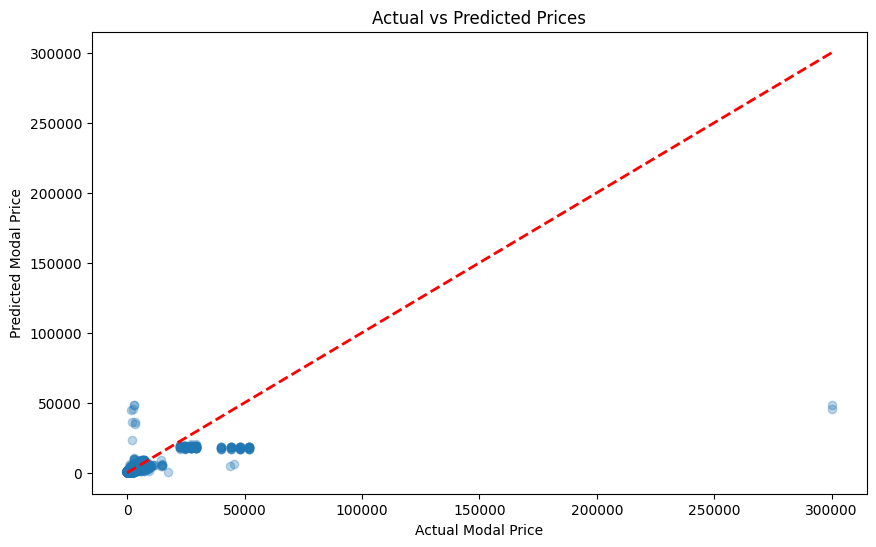

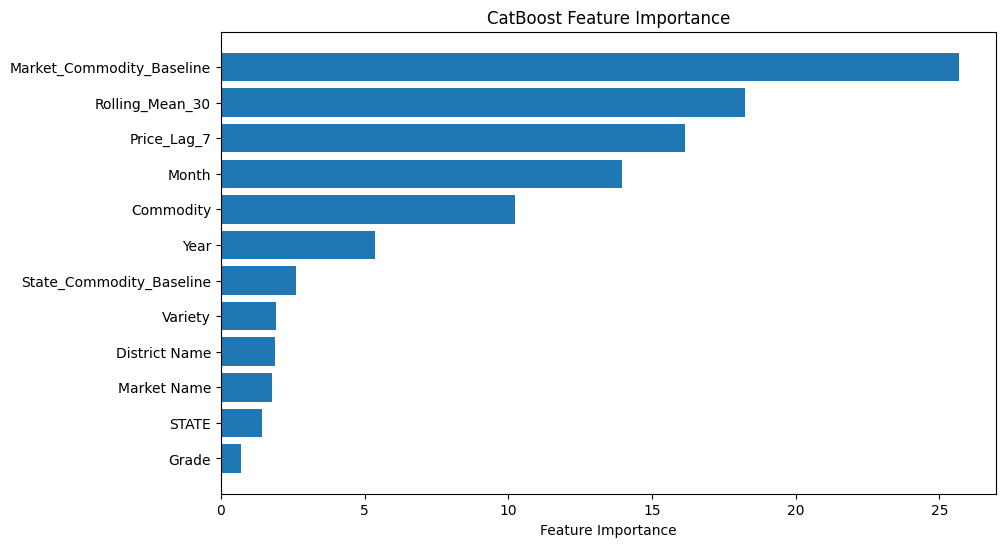

In [27]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Modal Price')
plt.ylabel('Predicted Modal Price')
plt.title('Actual vs Predicted Prices')
plt.savefig('actual_vs_predicted.png')

# Plot 2: Feature Importance
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(x_train.columns)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('CatBoost Feature Importance')
plt.savefig('feature_importance.png')